In [1]:
import sys
from pathlib import Path

# The notebooks are run from notebooks/, so the project root has to be on the path
# before any src.* import.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib

matplotlib.use("Agg")  # headless: the notebooks are executed in CI as well as by hand
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.reporting import configure_fonts

configure_fonts()  # CJK labels in charts render as boxes without this
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)


# 03 — Unsupervised anomaly detection

The nine rules in notebook 02 only find the patterns someone thought to write down. This
notebook covers the model that finds what the rules do not.

**Isolation Forest**, unsupervised: on a real engagement nobody hands you a column
marked "fraud". Training on injected labels would produce a model that had learned the
generator's patterns rather than anything about irregularity.

**Where the labels appear.** `anomaly_label` / `anomaly_type` are used in this notebook
for one purpose only — grading the model after the fact. They are never model inputs,
and this is disclosed on the dashboard as well.


## 1. Configuration and features

The inclusion test for a feature is that it can be stated as an audit question. If you cannot describe it to a partner, it does not belong in the matrix.

In [2]:
metrics = json.loads((PROJECT_ROOT / "outputs/reports/model_metrics.json").read_text())
evaluation = metrics["evaluation"]
hyperparameters = metrics["hyperparameters"]

print(f"model            {metrics['model']}")
for key, value in hyperparameters.items():
    print(f"  {key:15s} {value}")
print(f"features         {metrics['n_features']}")
print()
print("Feature list:")
for index, feature in enumerate(metrics["feature_columns"], start=1):
    print(f"  {index:2d}. {feature}")
print()
print("Imputed with the population median (undefined for some vouchers):")
for feature, value in metrics["imputed_features"].items():
    print(f"  {feature:34s} {value:,.3f}")
print()
print("NOTE:", metrics["note"])


model            IsolationForest
  n_estimators    300
  max_samples     auto
  contamination   0.03
  random_state    42
  scaler          StandardScaler
features         20

Feature list:
   1. amount
   2. log_amount
   3. amount_percentile
   4. vendor_transaction_count
   5. vendor_average_amount
   6. vendor_total_amount
   7. vendor_amount_ratio
   8. vendor_max_amount
   9. vendor_age_days
  10. days_since_last_transaction
  11. account_transaction_frequency
  12. is_weekend
  13. is_round_amount
  14. days_since_vendor_registration
  15. approval_time_hours
  16. payment_delay_hours
  17. same_vendor_daily_transactions
  18. description_length
  19. is_self_approval
  20. near_approval_threshold

Imputed with the population median (undefined for some vouchers):
  vendor_age_days                    2,146.000
  days_since_last_transaction        8.000
  days_since_vendor_registration     2,146.000
  payment_delay_hours                396.745

NOTE: Metrics are measured against a

## 2. Confusion matrix

The false negatives are the number that should worry an auditor. The false positives are the number that will annoy the client.

flagged by the model   904
injected anomalies     919

  true positives      263   caught
  false negatives     656   missed
  false positives     641   clean vouchers flagged
  true negatives   28,568

precision 0.2909   recall 0.2862   f1 0.2885   ROC-AUC 0.8162
false positives are 70.9% of the review list


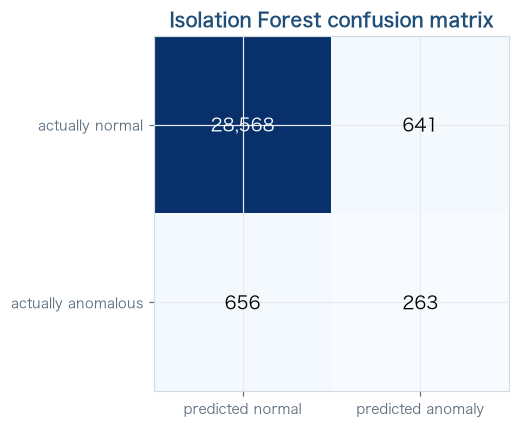

In [3]:
matrix = evaluation["confusion_matrix"]
true_negatives, false_positives = matrix[0]
false_negatives, true_positives = matrix[1]

print(f"flagged by the model   {evaluation['n_flagged']:,}")
print(f"injected anomalies     {evaluation['n_anomalies']:,}")
print()
print(f"  true positives   {true_positives:6,d}   caught")
print(f"  false negatives  {false_negatives:6,d}   missed")
print(f"  false positives  {false_positives:6,d}   clean vouchers flagged")
print(f"  true negatives   {true_negatives:6,d}")
print()
print(f"precision {evaluation['precision']:.4f}   recall {evaluation['recall']:.4f}   "
      f"f1 {evaluation['f1']:.4f}   ROC-AUC {evaluation['roc_auc']:.4f}")
print(f"false positives are {false_positives / max(evaluation['n_flagged'], 1):.1%} of the review list")

figure, axis = plt.subplots(figsize=(5, 4))
image = axis.imshow(matrix, cmap="Blues")
axis.set_xticks([0, 1], labels=["predicted normal", "predicted anomaly"])
axis.set_yticks([0, 1], labels=["actually normal", "actually anomalous"])
for row in range(2):
    for column in range(2):
        axis.text(column, row, f"{matrix[row][column]:,}", ha="center", va="center",
                  color="white" if matrix[row][column] > 1000 else "black", fontsize=12)
axis.set_title("Isolation Forest confusion matrix")
plt.tight_layout()
plt.show()


## 3. The operating point is a resourcing decision

Precision and recall at a fixed cut are not interesting on their own. What an audit team
actually chooses is how many vouchers it can work — so the useful curve is precision and
recall *against the review budget*.

random-selection baseline (the anomaly rate): 3.05%

At the top 0.5% (150 vouchers) precision is 47.0% - a 15x lift over random.
Recall matters more than precision in audit: a missed misstatement is an audit
failure, a false positive is a wasted hour. But recall is not free, and pretending
otherwise is how analytics projects lose the confidence of the people working the output.


,vouchers_reviewed,precision,recall,lift_vs_random
top_0.5%,150,47.0%,7.7%,15.4x
top_1.0%,301,38.2%,12.5%,12.5x
top_2.0%,602,33.3%,21.9%,10.9x
top_5.0%,"1,506",20.7%,34.0%,6.8x
top_10.0%,"3,012",14.5%,47.4%,4.7x


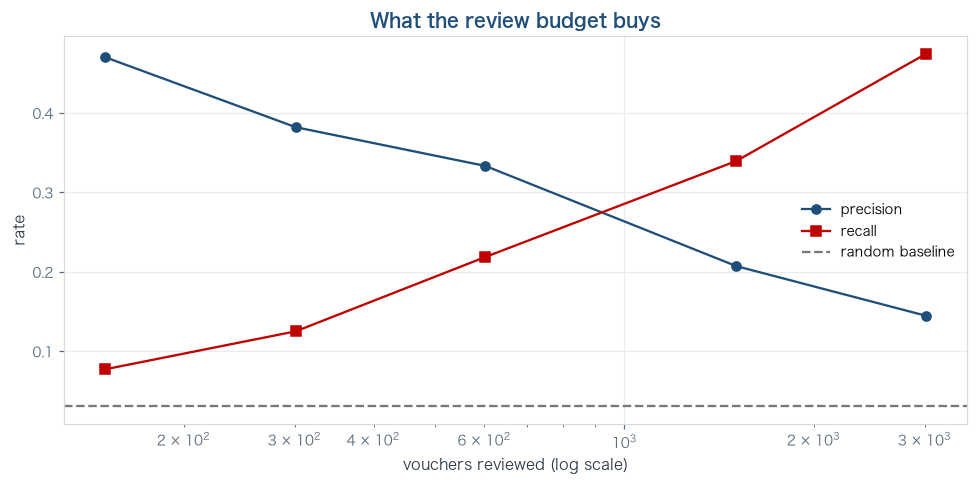

In [4]:
total = summary_vouchers = evaluation["n_samples"]
precision_at_k = evaluation["precision_at_k"]
recall_at_k = evaluation["recall_at_k"]

budget = pd.DataFrame(
    {
        "vouchers_reviewed": [int(float(key.replace("top_", "").replace("%", "")) / 100 * total)
                              for key in precision_at_k],
        "precision": list(precision_at_k.values()),
        "recall": list(recall_at_k.values()),
    },
    index=list(precision_at_k),
)
base_rate = evaluation["n_anomalies"] / total
budget["lift_vs_random"] = budget["precision"] / base_rate

display(budget.style.format({
    "vouchers_reviewed": "{:,.0f}", "precision": "{:.1%}", "recall": "{:.1%}",
    "lift_vs_random": "{:.1f}x",
}))

print(f"random-selection baseline (the anomaly rate): {base_rate:.2%}")

figure, axis = plt.subplots(figsize=(9, 4.5))
axis.plot(budget["vouchers_reviewed"], budget["precision"], marker="o", color="#1F4E79", label="precision")
axis.plot(budget["vouchers_reviewed"], budget["recall"], marker="s", color="#C00000", label="recall")
axis.axhline(base_rate, linestyle="--", color="#777777", label="random baseline")
axis.set_xscale("log")
axis.set_xlabel("vouchers reviewed (log scale)")
axis.set_ylabel("rate")
axis.set_title("What the review budget buys")
axis.legend()
plt.tight_layout()
plt.show()

print()
print(f"At the top 0.5% ({budget['vouchers_reviewed'].iloc[0]:,} vouchers) precision is "
      f"{budget['precision'].iloc[0]:.1%} - a {budget['lift_vs_random'].iloc[0]:.0f}x lift over random.")
print("Recall matters more than precision in audit: a missed misstatement is an audit")
print("failure, a false positive is a wasted hour. But recall is not free, and pretending")
print("otherwise is how analytics projects lose the confidence of the people working the output.")


## 4. Does the model add anything over the rules?

This is the question the project has to answer honestly, and the answer is
uncomfortable. It also has to be computed at the **anomaly** level, not the flag level:
the vouchers the model raised that no rule raised are almost entirely false positives,
so counting them as "anomalies the rules missed" would be wrong by two orders of
magnitude.

The overlap is reported on both bases below.

In [5]:
scored = pd.read_parquet(PROJECT_ROOT / "data/processed/transactions_scored.parquet")

rule = scored["rule_alert_count"].astype(int) > 0
model = scored["ml_anomaly_flag"].astype(bool)
truth = scored["anomaly_type"].astype("string").notna()

print("=== flag level: what an auditor would actually have to read ===")
print(f"  raised by a rule                     {int(rule.sum()):6,d}")
print(f"  raised by the model                  {int(model.sum()):6,d}")
print(f"  raised by both                       {int((rule & model).sum()):6,d}")
print(f"  raised by the model, no rule         {int((model & ~rule).sum()):6,d}")
print()
print("=== anomaly level: how many injected anomalies each one actually caught ===")
print(f"  injected anomalies                   {int(truth.sum()):6,d}")
print(f"  caught by a rule                     {int((truth & rule).sum()):6,d}")
print(f"  caught by the model                  {int((truth & model).sum()):6,d}")
print(f"  caught by both                       {int((truth & rule & model).sum()):6,d}")
print(f"  caught by the model ONLY             {int((truth & model & ~rule).sum()):6,d}")
print(f"  caught by a rule ONLY                {int((truth & rule & ~model).sum()):6,d}")
print(f"  caught by NEITHER                    {int((truth & ~rule & ~model).sum()):6,d}")
print()
print(f"  of the {int((model & ~rule).sum()):,} model-only flags, "
      f"{int((model & ~rule & truth).sum())} are real anomalies "
      f"({(model & ~rule & truth).sum() / max((model & ~rule).sum(), 1):.1%})")


=== flag level: what an auditor would actually have to read ===
  raised by a rule                      2,208
  raised by the model                     904
  raised by both                          660
  raised by the model, no rule            244

=== anomaly level: how many injected anomalies each one actually caught ===
  injected anomalies                      919
  caught by a rule                        902
  caught by the model                     263
  caught by both                          261
  caught by the model ONLY                  2
  caught by a rule ONLY                   641
  caught by NEITHER                        15

  of the 244 model-only flags, 2 are real anomalies (0.8%)


### The conclusion is that this benchmark cannot answer the question

The rules catch **98.2%** of the injected anomalies, and the model adds **2**. That is
not a failure of the model — it is a property of the benchmark. The anomalies were
injected to match the rule definitions, so the rules are near-exhaustive *by
construction*. A benchmark built from a rule set cannot measure what a model adds
beyond that rule set.

This matters because it is the single easiest number in the project to misquote. An
earlier version of the pipeline's own summary reported `detections_not_caught_by_rules
= 244`, which reads as "244 anomalies the rules missed" — and 242 of those 244 are false
positives. The summary now reports both bases under names that cannot be confused, and
`tests/test_reporting.py` pins the distinction.

What the model *does* establish is that it ranks well without labels: ROC-AUC 0.816 and
47% precision at the top 0.5%. The argument for keeping it is generalisation to patterns
nobody wrote a rule for — which is exactly what a synthetic benchmark with a known
answer key cannot test. Saying so is more useful than claiming a result the benchmark
cannot support.

## 5. Where the model's score actually separates the classes

The score distribution is what the ROC-AUC summarises. The overlap is the honest part: the classes are not cleanly separable, and no amount of tuning would make them so.

median score, normal vouchers     0.219
median score, injected anomalies  0.441

The distributions overlap heavily. A model that separated them cleanly on this
benchmark would be evidence of leakage, not of quality.


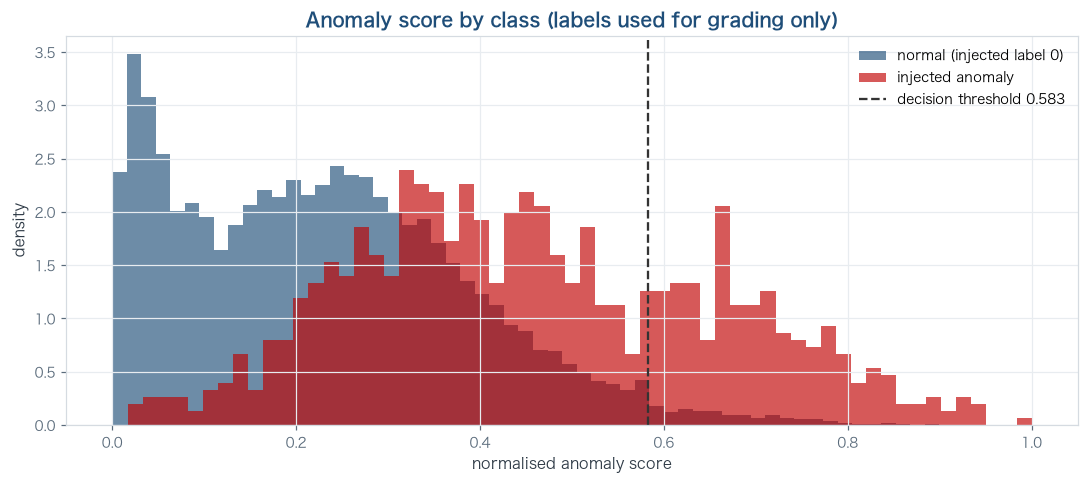

In [6]:
figure, axis = plt.subplots(figsize=(10, 4.5))
axis.hist(scored.loc[~truth, "anomaly_score"], bins=60, alpha=0.65,
          label="normal (injected label 0)", color="#1F4E79", density=True)
axis.hist(scored.loc[truth, "anomaly_score"], bins=60, alpha=0.65,
          label="injected anomaly", color="#C00000", density=True)
axis.axvline(evaluation["threshold"], linestyle="--", color="#333333",
             label=f"decision threshold {evaluation['threshold']:.3f}")
axis.set_xlabel("normalised anomaly score")
axis.set_ylabel("density")
axis.set_title("Anomaly score by class (labels used for grading only)")
axis.legend()
plt.tight_layout()
plt.show()

print(f"median score, normal vouchers     {scored.loc[~truth, 'anomaly_score'].median():.3f}")
print(f"median score, injected anomalies  {scored.loc[truth, 'anomaly_score'].median():.3f}")
print()
print("The distributions overlap heavily. A model that separated them cleanly on this")
print("benchmark would be evidence of leakage, not of quality.")


## 6. What this model does not do

In [7]:
for line in [
    "It does not detect fraud. It ranks vouchers by how unusual they look relative to",
    "  the rest of the ledger, which is a different question.",
    "Its reported metrics are an UPPER BOUND: the anomalies were injected by a generator",
    "  whose patterns are known, and real irregularities do not announce themselves.",
    "It is not tuned. Hyperparameters are defaults chosen for reproducibility; tuning",
    "  them against the injected labels would make the reported numbers even more optimistic.",
    "It explains itself at the feature level, not the voucher level. It can say which",
    "  features were extreme; it cannot say why an entry was made. That is the auditor's job.",
    "There is no temporal validation. A production deployment would need to check that",
    "  behaviour is stable across periods, and would need drift monitoring.",
]:
    print(line)


It does not detect fraud. It ranks vouchers by how unusual they look relative to
  the rest of the ledger, which is a different question.
Its reported metrics are an UPPER BOUND: the anomalies were injected by a generator
  whose patterns are known, and real irregularities do not announce themselves.
It is not tuned. Hyperparameters are defaults chosen for reproducibility; tuning
  them against the injected labels would make the reported numbers even more optimistic.
It explains itself at the feature level, not the voucher level. It can say which
  features were extreme; it cannot say why an entry was made. That is the auditor's job.
There is no temporal validation. A production deployment would need to check that
  behaviour is stable across periods, and would need drift monitoring.


## What this establishes

- **The model reaches ROC-AUC 0.816** with no labels, on 20 features each of which is
  expressible as an audit question.
- **At the top 0.5% of the ranking it is 47% precise — a 15x lift over random.** That is
  the usable operating point, and it is a resourcing decision, not a tuning knob.
- **On this benchmark the model adds almost nothing over the rules: 2 anomalies.** The
  rules catch 98.2% of the injected anomalies, because the anomalies were generated to
  match the rule definitions. That comparison is circular by construction, and this
  notebook does not claim otherwise.
- **The 244 figure is a flag count, not a detection count.** 242 of those 244 vouchers
  are false positives. Reporting it as "anomalies the rules missed" would be wrong by
  two orders of magnitude.
- **The score distributions overlap heavily**, which is the honest picture. Clean
  separation on a synthetic benchmark would indicate leakage, not quality.
- **Every metric here is an upper bound**, because the anomalies were injected by a
  generator whose patterns are known to the detectors.
